<a href="https://colab.research.google.com/github/Mateussouza011/IaModel/blob/main/notebooks/treinamentoPredictDiamantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Preço de Diamantes

In [17]:
!pip install tensorflow pandas seaborn scikit-learn joblib numpy matplotlib scikeras kagglehub -q

In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from scikeras.wrappers import KerasRegressor
import joblib
import kagglehub
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carregamento e Exploração dos Dados

In [21]:
path = kagglehub.dataset_download("zahranusrat/diamonds-characteristics-and-pricing-analysis")

print("Path to dataset files:", path)


df = pd.read_csv(f"{path}/diamonds.csv")
df.head(10)

Using Colab cache for faster access to the 'diamonds-characteristics-and-pricing-analysis' dataset.
Path to dataset files: /kaggle/input/diamonds-characteristics-and-pricing-analysis


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
5,0.24,Very Good,J,VVS2,62.8,57.0,3.94,3.96,2.48,336
6,0.24,Very Good,I,VVS1,62.3,57.0,3.95,3.98,2.47,336
7,0.26,Very Good,H,SI1,61.9,55.0,4.07,4.11,2.53,337
8,0.22,Fair,E,VS2,65.1,61.0,3.87,3.78,2.49,337
9,0.23,Very Good,H,VS1,59.4,61.0,4.00,4.05,2.39,338


In [22]:
df.describe()

,carat,depth,table,x,y,z,price
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734,3932.799722
std,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699,3989.439738
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,950.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.250000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [24]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price,0


### Remoção de Outliers (IQR)

In [ ]:
def remover_outliers_iqr(df, colunas):
    df_limpo = df.copy()
    for col in colunas:
        Q1 = df_limpo[col].quantile(0.25)
        Q3 = df_limpo[col].quantile(0.75)
        IQR = Q3 - Q1
        df_limpo = df_limpo[(df_limpo[col] >= Q1 - 1.5 * IQR) & (df_limpo[col] <= Q3 + 1.5 * IQR)]
    return df_limpo

tamanho_original = len(df)
df = remover_outliers_iqr(df, ['price', 'carat', 'x', 'y', 'z'])
tamanho_final = len(df)

print(f"Dados originais: {tamanho_original:,}")
print(f"Dados após IQR: {tamanho_final:,}")
print(f"Outliers removidos: {tamanho_original - tamanho_final:,} ({(tamanho_original - tamanho_final)/tamanho_original*100:.1f}%)")

## 2. Análise Exploratória

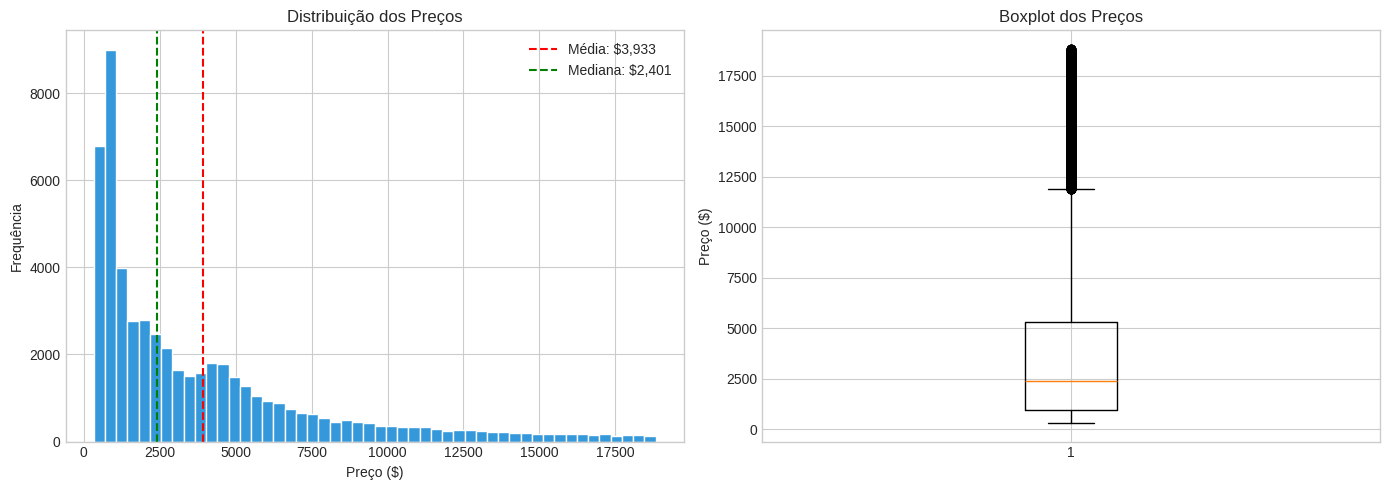

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Preço ($)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Preços')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Média: ${df['price'].mean():,.0f}")
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f"Mediana: ${df['price'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Preço ($)')
axes[1].set_title('Boxplot dos Preços')

plt.tight_layout()
plt.show()

### Matriz de Correlação

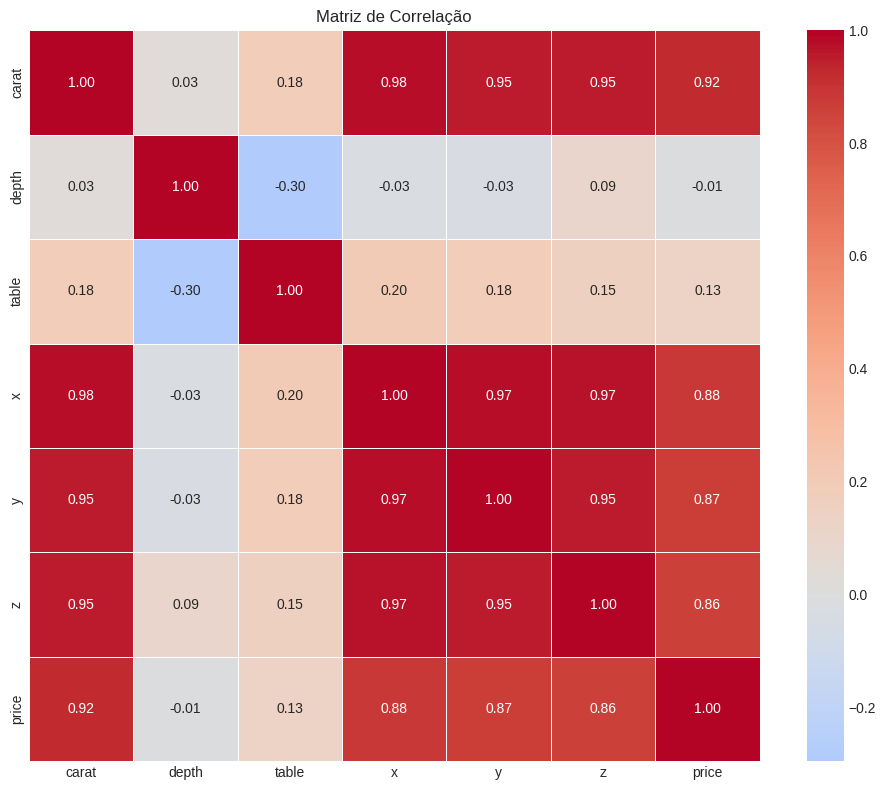

In [26]:
numerical_cols_corr = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
correlation_matrix = df[numerical_cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

### Carat vs Preço

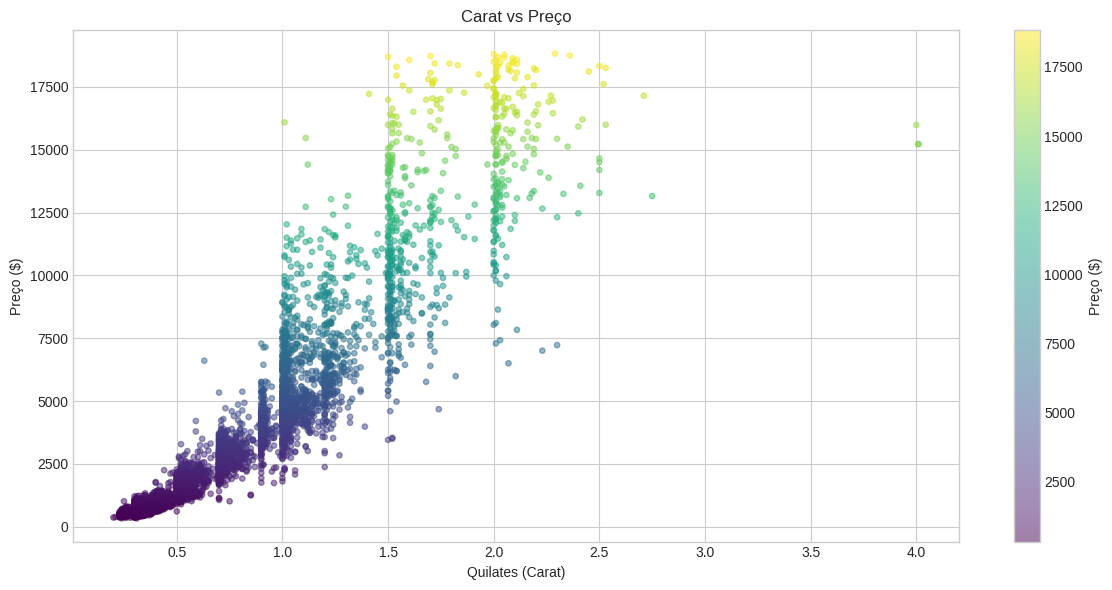

In [27]:
plt.figure(figsize=(12, 6))
sample = df.sample(5000, random_state=42)
scatter = plt.scatter(sample['carat'], sample['price'], alpha=0.5, c=sample['price'], cmap='viridis', s=15)
plt.colorbar(scatter, label='Preço ($)')
plt.xlabel('Quilates (Carat)')
plt.ylabel('Preço ($)')
plt.title('Carat vs Preço')
plt.tight_layout()
plt.show()

## 3. Pré-processamento

In [28]:
y = df['price']
X = df.drop('price', axis=1)

categorical_cols = ['cut', 'color', 'clarity']
numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

input_shape = X_train_processed.shape[1]

## 4. Treinamento dos Modelos

In [29]:
def create_model_1(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

def create_model_2(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

### Validação Cruzada (Cross-Validation)

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def build_model_cv():
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

model_cv = KerasRegressor(model=build_model_cv, epochs=20, batch_size=32, verbose=0)
cv_scores = cross_val_score(model_cv, X_train_processed, y_train, cv=kfold, scoring='neg_mean_absolute_error')

print("Cross-Validation (5-Fold):")
print(f"MAE por fold: {-cv_scores}")
print(f"MAE médio: ${-cv_scores.mean():,.2f} (+/- ${cv_scores.std():,.2f})")

In [30]:
model1 = create_model_1(input_shape)
history1 = model1.fit(X_train_processed, y_train, validation_split=0.2, batch_size=32, epochs=50, verbose=1)

model2 = create_model_2(input_shape)
history2 = model2.fit(X_train_processed, y_train, validation_split=0.2, batch_size=32, epochs=50, verbose=1)

Epoch 1/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3104.9670 - mae: 3104.9670 - val_loss: 773.2682 - val_mae: 773.2682
Epoch 2/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 704.8664 - mae: 704.8664 - val_loss: 594.9080 - val_mae: 594.9080
Epoch 3/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 579.8303 - mae: 579.8303 - val_loss: 525.7341 - val_mae: 525.7341
Epoch 4/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 514.8710 - mae: 514.8710 - val_loss: 480.4392 - val_mae: 480.4392
Epoch 5/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 473.6603 - mae: 473.6603 - val_loss: 444.6437 - val_mae: 444.6437
Epoch 6/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 451.8658 - mae: 451.8658 - val_loss: 410.4559 - val_mae: 410.4559
Epoch 7/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 427.5262 - mae: 427.5262 - val_loss: 389.1260 - val_mae: 389.1260
Epoch 8/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 394.7820 - mae: 394.7820 - val_loss: 373

### Histórico de Treinamento

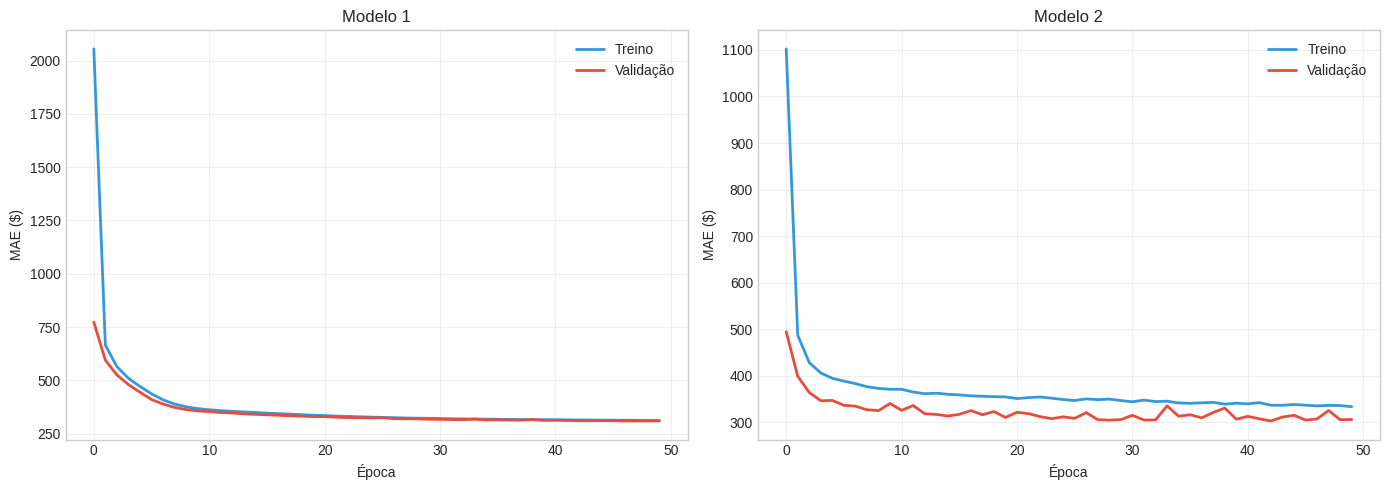

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['mae'], label='Treino', color='#3498db', linewidth=2)
axes[0].plot(history1.history['val_mae'], label='Validação', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MAE ($)')
axes[0].set_title('Modelo 1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history2.history['mae'], label='Treino', color='#3498db', linewidth=2)
axes[1].plot(history2.history['val_mae'], label='Validação', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE ($)')
axes[1].set_title('Modelo 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Avaliação

In [38]:
# Célula de Avaliação (Seção 5)

from sklearn.metrics import r2_score

loss1, mae1 = model1.evaluate(X_test_processed, y_test, verbose=0)
loss2, mae2 = model2.evaluate(X_test_processed, y_test, verbose=0)

pred1 = model1.predict(X_test_processed, verbose=0).flatten()
pred2 = model2.predict(X_test_processed, verbose=0).flatten()
pred_voting = (pred1 + pred2) / 2

mae_voting = np.mean(np.abs(y_test - pred_voting))

r2_1 = r2_score(y_test, pred1)
r2_2 = r2_score(y_test, pred2)
r2_voting = r2_score(y_test, pred_voting)

results = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Voting Ensemble'],
    'MAE ($)': [mae1, mae2, mae_voting],
    'R² (%)': [r2_1 * 100, r2_2 * 100, r2_voting * 100]
})
results

,Modelo,MAE ($),R² (%)
0,Modelo 1,307.636566,97.490299
1,Modelo 2,305.038177,97.700137
2,Voting Ensemble,303.689907,97.651494


### Previsão vs Real

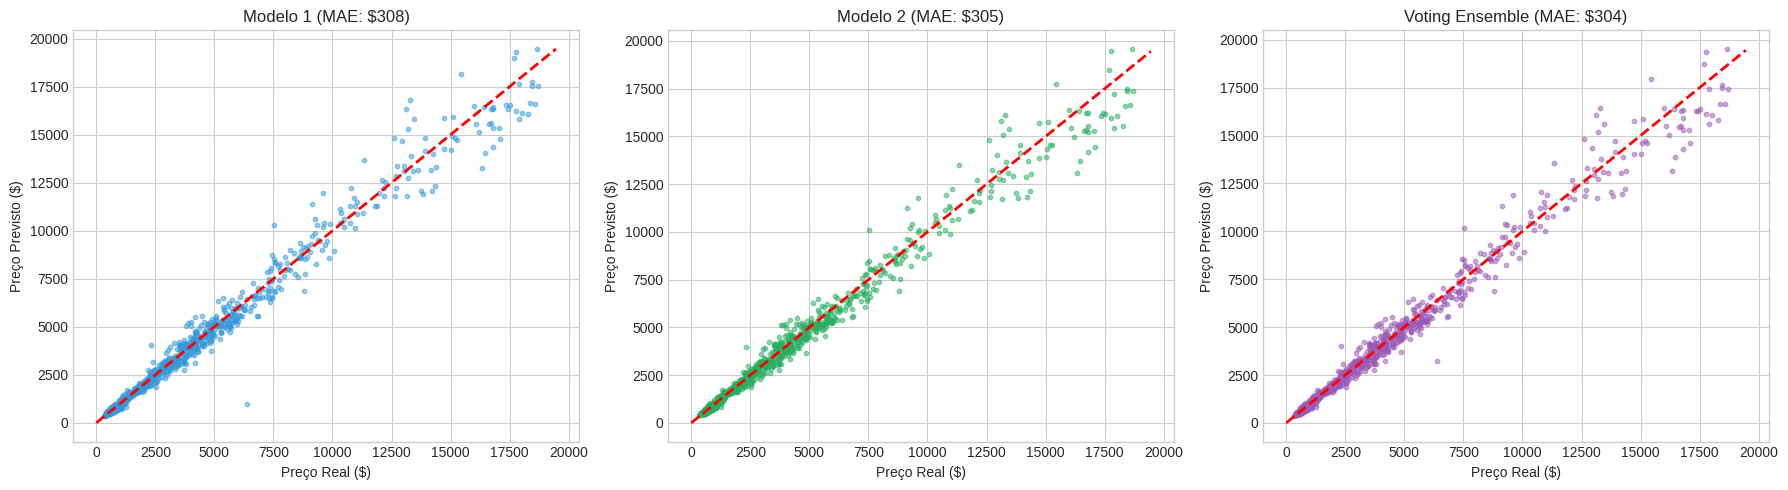

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_size = 1000
indices = np.random.choice(len(y_test), sample_size, replace=False)
y_sample = y_test.iloc[indices].values

max_val = max(y_sample.max(), pred1[indices].max())

axes[0].scatter(y_sample, pred1[indices], alpha=0.5, s=10, c='#3498db')
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[0].set_xlabel('Preço Real ($)')
axes[0].set_ylabel('Preço Previsto ($)')
axes[0].set_title(f'Modelo 1 (MAE: ${mae1:,.0f})')

axes[1].scatter(y_sample, pred2[indices], alpha=0.5, s=10, c='#27ae60')
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Preço Real ($)')
axes[1].set_ylabel('Preço Previsto ($)')
axes[1].set_title(f'Modelo 2 (MAE: ${mae2:,.0f})')

axes[2].scatter(y_sample, pred_voting[indices], alpha=0.5, s=10, c='#9b59b6')
axes[2].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[2].set_xlabel('Preço Real ($)')
axes[2].set_ylabel('Preço Previsto ($)')
axes[2].set_title(f'Voting Ensemble (MAE: ${mae_voting:,.0f})')

plt.tight_layout()
plt.show()

### Comparação de MAE

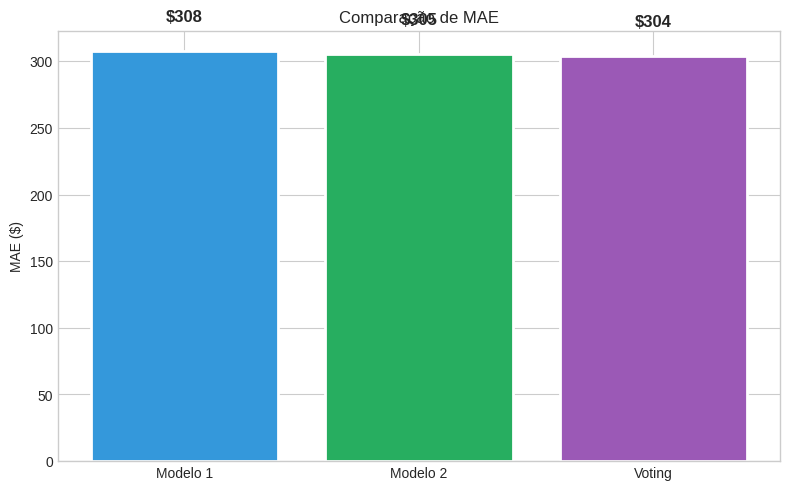

In [34]:
models_names = ['Modelo 1', 'Modelo 2', 'Voting']
maes = [mae1, mae2, mae_voting]
colors = ['#3498db', '#27ae60', '#9b59b6']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, maes, color=colors, edgecolor='white', linewidth=2)
plt.ylabel('MAE ($)')
plt.title('Comparação de MAE')

for bar, mae in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${mae:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Salvar Modelos

In [35]:
model1.save("model1.keras")
model2.save("model2.keras")
joblib.dump(preprocessor, "preprocessor.joblib")

import zipfile
with zipfile.ZipFile("models.zip", "w") as z:
    z.write("model1.keras")
    z.write("model2.keras")
    z.write("preprocessor.joblib")

from google.colab import files
files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Teste

In [36]:
loaded_model1 = keras.models.load_model("model1.keras")
loaded_model2 = keras.models.load_model("model2.keras")
loaded_preprocessor = joblib.load("preprocessor.joblib")

test_diamond = pd.DataFrame([{
    'carat': 1.0,
    'cut': 'Ideal',
    'color': 'G',
    'clarity': 'VS1',
    'depth': 61.5,
    'table': 55.0,
    'x': 6.5,
    'y': 6.5,
    'z': 4.0
}])

test_processed = loaded_preprocessor.transform(test_diamond)
pred1_test = loaded_model1.predict(test_processed, verbose=0)[0][0]
pred2_test = loaded_model2.predict(test_processed, verbose=0)[0][0]
pred_voting_test = (pred1_test + pred2_test) / 2

pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Voting'],
    'Previsão ($)': [pred1_test, pred2_test, pred_voting_test]
})

,Modelo,Previsão ($)
0,Modelo 1,6509.615723
1,Modelo 2,6365.719727
2,Voting,6437.667969
